In [1]:
import pandas as pd 
df = pd.read_csv("../data/processed/telco_cleaned.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [3]:
# Drop Customer ID first
df.drop('customerID', axis=1, inplace=True)

# Then encode

In [4]:
df.shape

(7043, 20)

In [5]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder
df_label_encoding=df.copy()
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
df.head(50)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
5,0,0,0,0,8,1,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,99.65,820.50,1
6,1,0,0,1,22,1,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,1,Credit card (automatic),89.10,1949.40,0
7,0,0,0,0,10,0,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,0,Mailed check,29.75,301.90,0
8,0,0,1,0,28,1,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,1,Electronic check,104.80,3046.05,1
9,1,0,0,1,62,1,No,DSL,Yes,Yes,No,No,No,No,One year,0,Bank transfer (automatic),56.15,3487.95,0


In [6]:
df.columns
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

(7043, 20)

In [7]:
#One-Hot Encoding
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]  
df=df.copy()
df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)


In [8]:
a=df
df.head(10)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
5,0,0,0,0,8,1,1,99.65,820.50,1,...,False,False,True,False,True,False,False,False,True,False
6,1,0,0,1,22,1,1,89.10,1949.40,0,...,False,False,True,False,False,False,False,True,False,False
7,0,0,0,0,10,0,0,29.75,301.90,0,...,False,False,False,False,False,False,False,False,False,True
8,0,0,1,0,28,1,1,104.80,3046.05,1,...,True,False,True,False,True,False,False,False,True,False
9,1,0,0,1,62,1,0,56.15,3487.95,0,...,False,False,False,False,False,True,False,False,False,False


In [9]:
#Feature Scaling (Standard Scaler)
from sklearn.preprocessing import StandardScaler

df_standard = df.copy()

scaler = StandardScaler()

df_standard[['tenure','MonthlyCharges','TotalCharges']] = (
    scaler.fit_transform(
        df[['tenure','MonthlyCharges','TotalCharges']]
    )
)

In [10]:

df_standard.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,False,False,False,False,False,False,False,False,True,False


In [11]:
#Feature Scaling (MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler
df_minmax=df.copy()
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

scaler = MinMaxScaler()

df_minmax[num_cols] = scaler.fit_transform(df[num_cols])

df_minmax.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.115423,0.001275,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.472222,1,0,0.385075,0.215867,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,0.027778,1,1,0.354229,0.010310,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.625000,0,0,0.239303,0.210241,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,0.027778,1,1,0.521891,0.015330,1,...,False,False,False,False,False,False,False,False,True,False


In [12]:
#Adding Avg Monthly spend Column
import numpy as np

df['AvgMonthlySpend'] = np.where(
    df['tenure'] == 0,
    0,
    df['TotalCharges'] / df['tenure']
)

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,True,False,29.850000
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,True,False,False,False,True,55.573529
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,True,54.075000
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,False,False,True,False,False,False,False,40.905556
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,True,False,75.825000


In [14]:
#Adding Service count column
service_cols = [
    'PhoneService',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

df['ServiceCount'] = df[service_cols].astype(int).sum(axis=1)
df['ServiceCount'] = df[service_cols].sum(axis=1)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,True,False,29.850000,1
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,True,False,False,False,True,55.573529,3
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,True,54.075000,3
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,False,True,False,False,False,False,40.905556,3
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,True,False,75.825000,1


In [16]:
df['ServiceCount'].value_counts()

ServiceCount
1    2253
4    1062
3    1041
2     996
5     827
6     525
7     259
0      80
Name: count, dtype: int64

In [17]:
#as it does not specify start and end date
#Adding Contract Value Column

df['ContractValue'] = (
    df['MonthlyCharges'] *
    df['tenure']
)

In [18]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Churn'] = le.fit_transform(df['Churn'])

In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [21]:
#Feature Selection (Correlation Based Filtering
corr_matrix = df.corr(numeric_only=True)

corr_with_target = corr_matrix['Churn'].abs()

corr_with_target.sort_values(
    ascending=False
)

Churn                                    1.000000
tenure                                   0.352229
InternetService_Fiber optic              0.308020
Contract_Two year                        0.302253
PaymentMethod_Electronic check           0.301919
TechSupport_No internet service          0.227890
OnlineBackup_No internet service         0.227890
InternetService_No                       0.227890
OnlineSecurity_No internet service       0.227890
StreamingTV_No internet service          0.227890
DeviceProtection_No internet service     0.227890
StreamingMovies_No internet service      0.227890
TotalCharges                             0.199037
ContractValue                            0.198514
MonthlyCharges                           0.193356
AvgMonthlySpend                          0.193301
PaperlessBilling                         0.191825
Contract_One year                        0.177820
OnlineSecurity_Yes                       0.171226
TechSupport_Yes                          0.164674


In [22]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ContractValue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370,64.698218,2279.581350
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561,30.270670,2264.729447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000,35.649000,394.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,70.300000,1393.600000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,90.174158,3786.100000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,121.400000,8550.000000


In [23]:
#Feature Selection Using Mutual Information
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

X = df.drop('Churn', axis=1)
y = df['Churn']

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='MI Score',
    ascending=False
)

print(mi_df.head(40))

                                  Feature  MI Score
4                                  tenure  0.083560
26                      Contract_Two year  0.067996
32                          ContractValue  0.051028
7                          MonthlyCharges  0.049532
11            InternetService_Fiber optic  0.047673
8                            TotalCharges  0.043686
28         PaymentMethod_Electronic check  0.040225
12                     InternetService_No  0.036977
13     OnlineSecurity_No internet service  0.035161
30                        AvgMonthlySpend  0.034833
19        TechSupport_No internet service  0.032695
23    StreamingMovies_No internet service  0.026536
6                        PaperlessBilling  0.024780
17   DeviceProtection_No internet service  0.022644
15       OnlineBackup_No internet service  0.022610
21        StreamingTV_No internet service  0.021024
20                        TechSupport_Yes  0.018864
27  PaymentMethod_Credit card (automatic)  0.017484
14          

In [24]:
top_features = mi_df.head(10)

print(top_features)

                               Feature  MI Score
4                               tenure  0.083560
26                   Contract_Two year  0.067996
32                       ContractValue  0.051028
7                       MonthlyCharges  0.049532
11         InternetService_Fiber optic  0.047673
8                         TotalCharges  0.043686
28      PaymentMethod_Electronic check  0.040225
12                  InternetService_No  0.036977
13  OnlineSecurity_No internet service  0.035161
30                     AvgMonthlySpend  0.034833


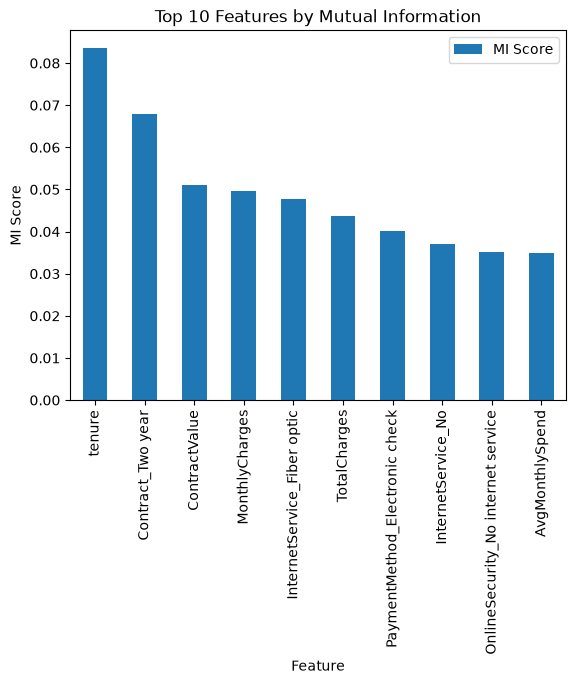

In [25]:
import matplotlib.pyplot as plt

mi_df.head(10).plot(
    x='Feature',
    y='MI Score',
    kind='bar'
)

plt.title("Top 10 Features by Mutual Information")
plt.ylabel("MI Score")
plt.show()

In [26]:
df.shape

(7043, 34)

In [27]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ContractValue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2281.916928,0.265370,64.698218,2279.581350
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2265.270398,0.441561,30.270670,2264.729447
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,402.225000,0.000000,35.649000,394.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,0.000000,70.300000,1393.600000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,90.174158,3786.100000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,121.400000,8550.000000


In [28]:
#Class imbalance using SMOTE
from imblearn.over_sampling import SMOTE

X = df.drop('Churn', axis=1)
y = df['Churn']

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

print(y_smote.value_counts())

Churn
0    5174
1    5174
Name: count, dtype: int64


In [29]:
#Class Imbalance using Random ZUnder sampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    random_state=42
)

X_under, y_under = rus.fit_resample(X, y)

print(y_under.value_counts())


Churn
0    1869
1    1869
Name: count, dtype: int64


In [30]:
#Splitting data into 70% train , 15% validation and 15% test 
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [31]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [32]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4930, 33)
Validation: (1056, 33)
Test: (1057, 33)


In [33]:
print(y_train.value_counts(normalize=True))

print(y_val.value_counts(normalize=True))

print(y_test.value_counts(normalize=True))

Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64
Churn
0    0.734848
1    0.265152
Name: proportion, dtype: float64
Churn
0    0.734153
1    0.265847
Name: proportion, dtype: float64


In [34]:
df.to_csv("../data/processed/telco_processed.csv", index=False)